In [62]:
# pip install -U langgraph
# pip install -U "langchain[openai]"

In [ ]:
import os
from langchain.chat_models import init_chat_model

os.environ["OPENAI_API_KEY"] = ""

llm = init_chat_model("openai:gpt-4.1-mini")

In [2]:
from typing import Annotated

from typing_extensions import TypedDict

from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages


class State(TypedDict):
    # Messages have the type "list". The `add_messages` function
    # in the annotation defines how this state key should be updated
    # (in this case, it appends messages to the list, rather than overwriting them)
    messages: Annotated[list, add_messages]
    is_done: bool = False


graph_builder = StateGraph(State)

In [3]:
def chatbot(state: State):
    return {"messages": [llm.invoke(state["messages"])], "is_done": True}

def mark_done(state: State):
    print("Marking done")
    print(state)
    print("okoo=====")
    return {"messages": state["messages"]}

# The first argument is the unique node name
# The second argument is the function or object that will be called whenever
# the node is used.
graph_builder.add_node("chatbot", chatbot)
graph_builder.add_node("mark_done", mark_done)

In [4]:
graph_builder.add_edge(START, "chatbot")
graph_builder.add_edge("chatbot", "mark_done")
graph_builder.add_edge("mark_done", END)


In [5]:
graph = graph_builder.compile()


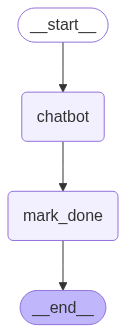

In [6]:
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    # This requires some extra dependencies and is optional
    pass

In [7]:
def stream_graph_updates(user_input: str):
    for event in graph.stream({"messages": [{"role": "user", "content": user_input}]}):
        print(event)
        for value in event.values():
            print("Assistant:", value["messages"][-1].content)


while True:
    try:
        user_input = input("User: ")
        if user_input.lower() in ["quit", "exit", "q"]:
            print("Goodbye!")
            break
        stream_graph_updates(user_input)
    except:
        # fallback if input() is not available
        user_input = "What do you know about LangGraph?"
        print("User: " + user_input)
        stream_graph_updates(user_input)
        break

{'chatbot': {'messages': [AIMessage(content='Hello! How can I assist you today?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 9, 'prompt_tokens': 7, 'total_tokens': 16, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4.1-mini-2025-04-14', 'system_fingerprint': 'fp_6f2eabb9a5', 'id': 'chatcmpl-Bo0srWWruDmZdexq4jm1yZbf3yRqp', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='run--4f7fbeb2-1317-43a0-8d8e-e8a519757e8f-0', usage_metadata={'input_tokens': 7, 'output_tokens': 9, 'total_tokens': 16, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})], 'is_done': True}}
Assistant: Hello! How can I assist you today?
Marking done
{'messages': [HumanMessage(content='', additional_kwargs={}, res

In [8]:
from openai import OpenAI

client = OpenAI()

tools = [{
    "type": "function",
    "name": "get_weather",
    "description": "Get current temperature for a given location.",
    "parameters": {
        "type": "object",
        "properties": {
            "location": {
                "type": "string",
                "description": "City and country e.g. Bogotá, Colombia"
            }
        },
        "required": [
            "location"
        ],
        "additionalProperties": False
    }
}]

response = client.responses.create(
    model="gpt-4.1-mini",
    input=[{"role": "user", "content": "What is the weather like in Paris today?"}],
    tools=tools
)

print(response.output)

[ResponseFunctionToolCall(arguments='{"location":"Paris, France"}', call_id='call_YzkbQ83aF64a3JHMqEkxcQF3', name='get_weather', type='function_call', id='fc_6862196e614c8198aae45db414445e9f01d3a14619196622', status='completed')]


In [9]:
from langchain_core.tools import tool


# Define tools
@tool
def multiply(a: int, b: int) -> int:
    """Multiply a and b.

    Args:
        a: first int
        b: second int
    """
    return a * b


@tool
def add(a: int, b: int) -> int:
    """Adds a and b.

    Args:
        a: first int
        b: second int
    """
    print("Adding", a, "and", b)
    return a + b


@tool
def divide(a: int, b: int) -> float:
    """Divide a and b.

    Args:
        a: first int
        b: second int
    """
    return a / b


# Augment the LLM with tools
tools = [add, multiply, divide]
tools_by_name = {tool.name: tool for tool in tools}
llm_with_tools = llm.bind_tools(tools)

In [10]:
ouput = llm_with_tools.invoke("3 * 5 bằng mấy")

In [11]:
ouput.additional_kwargs

{'tool_calls': [{'id': 'call_zqVVw9rOV65hwI6h39CLgKpd',
   'function': {'arguments': '{"a":3,"b":5}', 'name': 'multiply'},
   'type': 'function'}],
 'refusal': None}

In [12]:
ouput.dict().keys()

/var/folders/s3/6vj_8yv17fd3fqz78ydh_f400000gn/T/ipykernel_42367/1152699381.py:1: PydanticDeprecatedSince20: The `dict` method is deprecated; use `model_dump` instead. Deprecated in Pydantic V2.0 to be removed in V3.0. See Pydantic V2 Migration Guide at https://errors.pydantic.dev/2.11/migration/
  ouput.dict().keys()


dict_keys(['content', 'additional_kwargs', 'response_metadata', 'type', 'name', 'id', 'example', 'tool_calls', 'invalid_tool_calls', 'usage_metadata'])

In [13]:
ouput.tool_calls

[{'name': 'multiply',
  'args': {'a': 3, 'b': 5},
  'id': 'call_zqVVw9rOV65hwI6h39CLgKpd',
  'type': 'tool_call'}]

In [14]:
ouput2 = llm_with_tools.invoke("xin chào")

In [15]:
ouput2.tool_calls

[]

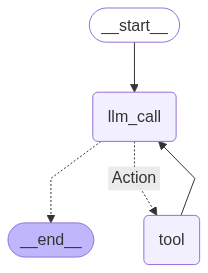

================================ Human Message =================================

cộng 6 and 4 sau lấy kết quả nhân với 5 
================================== Ai Message ==================================
Tool Calls:
  add (call_KQjhFmIQVBHRy6QthmaQK1K2)
 Call ID: call_KQjhFmIQVBHRy6QthmaQK1K2
  Args:
    a: 6
    b: 4
  multiply (call_mEV2e5pn0VUGzhFy2bjS9liZ)
 Call ID: call_mEV2e5pn0VUGzhFy2bjS9liZ
  Args:
    a: 10
    b: 5
================================= Tool Message =================================

10
================================= Tool Message =================================

50
================================== Ai Message ==================================

Đầu tiên, cộng 6 và 4 được kết quả 10. Sau đó, lấy kết quả này nhân với 5 sẽ được 50.


In [105]:
from langgraph.graph import MessagesState
from langchain_core.messages import SystemMessage, HumanMessage, ToolMessage
from typing_extensions import Literal
from langchain_core.messages import HumanMessage, SystemMessage
from langgraph.graph import StateGraph, START, END


# Nodes
def llm_call(state: MessagesState):
    """LLM decides whether to call a tool or not"""

    return {
        "messages": [
            llm_with_tools.invoke(
                [
                    SystemMessage(
                        content="You are a helpful assistant tasked with performing arithmetic on a set of inputs."
                    )
                ]
                + state["messages"]
            )
        ]
    }


def tool_node(state: dict):
    """Performs the tool call"""

    result = []
    for tool_call in state["messages"][-1].tool_calls:
        tool = tools_by_name[tool_call["name"]]
        observation = tool.invoke(tool_call["args"])
        result.append(ToolMessage(content=observation, tool_call_id=tool_call["id"]))
    return {"messages": result}


# Conditional edge function to route to the tool node or end based upon whether the LLM made a tool call
def should_continue(state: MessagesState) -> Literal["environment", END]:
    """Decide if we should continue the loop or stop based upon whether the LLM made a tool call"""

    messages = state["messages"]
    last_message = messages[-1]
    # If the LLM makes a tool call, then perform an action
    if last_message.tool_calls:
        return "Action"
    # Otherwise, we stop (reply to the user)
    return END


# Build workflow
agent_builder = StateGraph(MessagesState)

# Add nodes
agent_builder.add_node("llm_call", llm_call)
agent_builder.add_node("tool", tool_node)

# Add edges to connect nodes
agent_builder.add_edge(START, "llm_call")
agent_builder.add_conditional_edges(
    "llm_call",
    should_continue,
    {
        # Name returned by should_continue : Name of next node to visit
        "Action": "tool",
        END: END,
    },
)
agent_builder.add_edge("tool", "llm_call")

# Compile the agent
agent = agent_builder.compile()

# Show the agent
display(Image(agent.get_graph(xray=True).draw_mermaid_png()))

# Invoke
messages = [HumanMessage(content="cộng 6 and 4 sau lấy kết quả nhân với 5 ")]
messages = agent.invoke({"messages": messages})
for m in messages["messages"]:
    m.pretty_print()

In [16]:
from langchain_openai import ChatOpenAI
from langgraph.prebuilt import create_react_agent
from langgraph_supervisor import create_supervisor

def book_hotel(hotel_name: str):
    """Book a hotel"""
    return f"Successfully booked a stay at {hotel_name}."

def book_flight(from_airport: str, to_airport: str):
    """Book a flight"""
    return f"Successfully booked a flight from {from_airport} to {to_airport}."

flight_assistant = create_react_agent(
    model="openai:gpt-4o",
    tools=[book_flight],
    prompt="You are a flight booking assistant",
    name="flight_assistant"
)

hotel_assistant = create_react_agent(
    model="openai:gpt-4o",
    tools=[book_hotel],
    prompt="You are a hotel booking assistant",
    name="hotel_assistant"
)

supervisor = create_supervisor(
    agents=[flight_assistant, hotel_assistant],
    model=ChatOpenAI(model="gpt-4o"),
    prompt=(
        "You manage a hotel booking assistant and a"
        "flight booking assistant. Assign work to them."
    )
).compile()

for chunk in supervisor.stream(
    {
        "messages": [
            {
                "role": "user",
                "content": "book a flight from BOS to JFK and a stay at McKittrick Hotel"
            }
        ]
    }
):
    print(chunk)
    print("\n")

Task supervisor with path ('__pregel_pull', 'supervisor') wrote to unknown channel is_last_step, ignoring it.
Task supervisor with path ('__pregel_pull', 'supervisor') wrote to unknown channel remaining_steps, ignoring it.


{'supervisor': {'messages': [HumanMessage(content='book a flight from BOS to JFK and a stay at McKittrick Hotel', additional_kwargs={}, response_metadata={}, id='dbd106b6-e595-4df4-ba6f-35424f98c2f8'), AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'call_WeyzRILQ4ZMA4nEWPnk1S4K3', 'function': {'arguments': '{}', 'name': 'transfer_to_flight_assistant'}, 'type': 'function'}], 'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 14, 'prompt_tokens': 100, 'total_tokens': 114, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_07871e2ad8', 'id': 'chatcmpl-Bo0t5F1dCb3pquRXUcBCbWDsHg5XJ', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, name='supervisor', id='run--e4811248-ccea-4101-bb9d-b95aca53dfff-0', tool_calls=[

Task supervisor with path ('__pregel_pull', 'supervisor') wrote to unknown channel is_last_step, ignoring it.
Task supervisor with path ('__pregel_pull', 'supervisor') wrote to unknown channel remaining_steps, ignoring it.


{'supervisor': {'messages': [HumanMessage(content='book a flight from BOS to JFK and a stay at McKittrick Hotel', additional_kwargs={}, response_metadata={}, id='dbd106b6-e595-4df4-ba6f-35424f98c2f8'), AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'call_WeyzRILQ4ZMA4nEWPnk1S4K3', 'function': {'arguments': '{}', 'name': 'transfer_to_flight_assistant'}, 'type': 'function'}], 'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 14, 'prompt_tokens': 100, 'total_tokens': 114, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_07871e2ad8', 'id': 'chatcmpl-Bo0t5F1dCb3pquRXUcBCbWDsHg5XJ', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, name='supervisor', id='run--e4811248-ccea-4101-bb9d-b95aca53dfff-0', tool_calls=[

In [17]:
# pip install langgraph_supervisor
# 